In [2]:
from google.colab import drive
drive.mount('/content/drive')
!nvidia-smi --query-gpu=name,memory.total --format=csv
import os
REPO = '/content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance'
print(os.listdir(REPO))
!free -g; nproc

Mounted at /content/drive
name, memory.total [MiB]
Tesla T4, 15360 MiB
['.gitignore', 'GUIDE.md', 'README.md', 'RUBRIC.md', 'eval.py', 'tests', 'starter', '.git']
               total        used        free      shared  buff/cache   available
Mem:              12           1           7           0           3          11
Swap:              0           0           0
2


In [3]:
# Tải dữ liệu: ảnh (Zenodo, kiểm tra MD5, lưu bản sao zip trên Drive để phiên sau không phải tải lại) + nhãn fold 0 (GitHub tác giả)
import os, hashlib, shutil, subprocess
DATA = '/content/data'; os.makedirs(f'{DATA}/labels', exist_ok=True)
ZIP = f'{DATA}/images.zip'; ZIP_DRIVE = '/content/drive/MyDrive/VinAI/deepweeds_images.zip'
if not os.path.exists(ZIP):
    if os.path.exists(ZIP_DRIVE):
        shutil.copy(ZIP_DRIVE, ZIP)
    else:
        !wget -q -O {ZIP} "https://zenodo.org/records/7939060/files/images.zip?download=1"
h = hashlib.md5()
with open(ZIP, 'rb') as f:
    for chunk in iter(lambda: f.read(1 << 20), b''): h.update(chunk)
assert h.hexdigest() == 'b7b30f96d466fba86016aa5a26606e0f', f'MD5 sai: {h.hexdigest()}'
print('MD5 OK')
if not os.path.exists(ZIP_DRIVE): shutil.copy(ZIP, ZIP_DRIVE)
!unzip -q -n {ZIP} -d {DATA}/images
!ls {DATA}/images | head -3; ls {DATA}/images | wc -l
BASE = 'https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels'
for name in ['labels', 'train_subset0', 'val_subset0', 'test_subset0']:
    !wget -q -O {DATA}/labels/{name}.csv {BASE}/{name}.csv
!wc -l {DATA}/labels/*.csv; head -3 {DATA}/labels/train_subset0.csv
!pip list 2>/dev/null | grep -i -E "^(torch|torchvision|timm|numpy|pandas|openpyxl|matplotlib|scikit-learn) "

MD5 OK
20160928-140314-0.jpg
20160928-140337-0.jpg
20160928-140731-0.jpg
17509
  17510 /content/data/labels/labels.csv
   3508 /content/data/labels/test_subset0.csv
  10502 /content/data/labels/train_subset0.csv
   3502 /content/data/labels/val_subset0.csv
  35022 total
Filename,Label
20171109-175921-2.jpg,5
20170714-142019-3.jpg,1
matplotlib                            3.10.0
numpy                                 2.1.3
openpyxl                              3.1.5
pandas                                2.2.3
scikit-learn                          1.6.1
timm                                  1.0.29
torch                                 2.11.0+cu130
torchvision                           0.26.0+cu130


In [29]:
# Đồng bộ code: giải nén code_bundle.tgz (tải lên /content) vào thư mục code/ của bài nộp trên Drive
import os, tarfile, sys
SUB = REPO + '/submissions/MSSV_ho_ten'; CODE = SUB + '/code'
os.makedirs(CODE, exist_ok=True)
if os.path.exists('/content/code_bundle.tgz'):
    with tarfile.open('/content/code_bundle.tgz') as t:
        t.extractall(CODE); print('cập nhật:', t.getnames())
    os.remove('/content/code_bundle.tgz')
os.environ.update(LAB_SUB=SUB, LAB_DATA='/content/data', LAB_EPOCHS='10', PYTHONUNBUFFERED='1')
%cd {CODE}
!python -m unittest test_code 2>&1 | tail -5

/tmp/ipykernel_1601/3430678476.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(CODE); print('cập nhật:', t.getnames())


cập nhật: ['benchmark.py', 'dataset.py', 'inference.py', 'losses.py', 'make_results.py', 'model.py', 'run_experiments.py', 'test_code.py', 'train.py']
/content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/MSSV_ho_ten/code
.................
----------------------------------------------------------------------
Ran 21 tests in 36.099s

OK


In [5]:
# Chạy nền (nohup) để notebook vẫn dùng được; log ghi ra Drive: <SUB>/logs/<tên>.log
import subprocess, os
def launch(name, *stages):
    os.makedirs(f'{SUB}/logs', exist_ok=True)
    cmd = ' && '.join(f'python run_experiments.py {s}' for s in stages)
    subprocess.Popen(f'nohup sh -c "{cmd}" > {SUB}/logs/{name}.log 2>&1 &', shell=True, cwd=CODE)
    print('launched', name, ':', cmd)
launch('step0_1', '--stage eda', '--stage sanity --backbone resnet50', '--stage backbones')

launched step0_1 : python run_experiments.py --stage eda && python run_experiments.py --stage sanity --backbone resnet50 && python run_experiments.py --stage backbones


In [55]:
# Theo dõi tiến độ (chạy lại ô này)
import glob, json
for f in sorted(glob.glob(SUB + '/runs/*/seed*/summary.json')):
    s = json.load(open(f)); print(s['exp_id'], s['seed'], s['desc'][:14], 'F1 %.4f top1 %.4f ep %d' % (s['val_macro_f1'], s['val_top1'], s['best_epoch']), 'rawEMA %.4f' % s['val_macro_f1_raw_best'] if 'val_macro_f1_raw_best' in s else '')
!grep -h -E " ep |xong|Error|error|Traceback|Chọn" {SUB}/logs/*.log | tail -n 3 | cut -c1-200; nvidia-smi --query-gpu=utilization.gpu,memory.used --format=csv,noheader

B01 0 resnet50 F1 0.7850 top1 0.8446 ep 9 
B02 0 convnext_tiny F1 0.9676 top1 0.9760 ep 9 
B03 0 deit_small F1 0.9460 top1 0.9617 ep 9 
B04 0 efficientnet_b F1 0.7238 top1 0.8021 ep 7 
B05 0 mobilenetv3 F1 0.5997 top1 0.7207 ep 7 
F01 0 final F1 0.9703 top1 0.9771 ep 9 
F01 1 final F1 0.9652 top1 0.9726 ep 9 
F01 2 final F1 0.9683 top1 0.9743 ep 10 
T00 0 baseline F1 0.9676 top1 0.9760 ep 9 
T00 1 baseline F1 0.9697 top1 0.9771 ep 9 
T00 2 baseline F1 0.9680 top1 0.9754 ep 10 
T01 0 scratch F1 0.2999 top1 0.5493 ep 8 
T02 0 frozen F1 0.8433 top1 0.8772 ep 10 
T03 0 trivialaug F1 0.9694 top1 0.9766 ep 10 
T04 0 cutmix F1 0.9703 top1 0.9771 ep 9 
T05 0 labelsmooth F1 0.9687 top1 0.9763 ep 10 
T06 0 focal F1 0.9694 top1 0.9766 ep 9 
T07 0 ce_weighted F1 0.9641 top1 0.9709 ep 9 
T08 0 ema F1 0.9701 top1 0.9766 ep 10 rawEMA 0.9705
T09 0 balanced_sampl F1 0.9679 top1 0.9746 ep 7 
T10 0 combo_mix-cutm F1 0.9651 top1 0.9732 ep 9 rawEMA 0.9683
[F01 s2] ep  9 train_loss 0.5020 val_loss 0.0935 va

In [56]:
# Bước 4: tính chỉ số bằng eval.py gốc (score) và tự chấm phần I (grade)
L = '/content/data/labels'; P = SUB + '/predictions'; O = SUB + '/eval_out'
!python {REPO}/eval.py score --pred "{P}/F01_seed*_test.csv" --test-csv {L}/test_subset0.csv --labels {L}/labels.csv --tag F01 --out {O} > {O}_F01.txt 2>&1; mkdir -p {O}; mv {O}_F01.txt {O}/score_F01.txt
!python {REPO}/eval.py score --pred "{P}/T00_seed*_test.csv" --test-csv {L}/test_subset0.csv --labels {L}/labels.csv --tag T00 --out {O} > {O}/score_T00.txt 2>&1
!python {REPO}/eval.py score --pred "{P}/F01uncal_seed*_test.csv" --test-csv {L}/test_subset0.csv --labels {L}/labels.csv --tag F01uncal --out {O} > {O}/score_F01uncal.txt 2>&1
!python {REPO}/eval.py grade --final "{P}/F01_seed*_test.csv" --baseline "{P}/T00_seed*_test.csv" --uncal "{P}/F01uncal_seed*_test.csv" --final-val "{P}/F01_seed*_val.csv" --latency-p95-ms 17.70 --latency-method proper --test-csv {L}/test_subset0.csv --labels {L}/labels.csv --out {O} > {O}/grade.txt 2>&1
!ls {O}; cat {O}/grade.txt

F01_confusion_sum.csv	    F01uncal_per_seed.csv  score_T00.txt
F01_per_class.csv	    F01uncal_summary.json  T00_confusion_sum.csv
F01_per_seed.csv	    grade_I.json	   T00_per_class.csv
F01_summary.json	    grade.txt		   T00_per_seed.csv
F01uncal_confusion_sum.csv  score_F01.txt	   T00_summary.json
F01uncal_per_class.csv	    score_F01uncal.txt
## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 97.92% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 4 | 5 | final 0.9750, mốc 0.9706, Δ=+0.0044, s=0.0026 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 95.1% (mốc 88.5%), Snake Weed 94.6% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 1 | 1 | trước 0.0344, sau 0.0072 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9719, test 0.9750, chênh 0.0031 |
| I5 | Cấu hình thời gian thực | 2 | 2 | p95 = 17.7 ms (ngân sách 100 ms), đo đúng cách |

**Tổng các ý đã chấm: 19 / 20

In [57]:
# Bước 5: results.xlsx + biểu đồ
!python make_results.py --backbone convnext_tiny 2>&1 | grep -v -i warn | tail -5
!ls {SUB} {SUB}/figures {SUB}/curves; ls {SUB}/predictions | wc -l

đã ghi /content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/MSSV_ho_ten/results.xlsx
/content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/MSSV_ho_ten:
code	discarded_F01_combo  figures  predictions   runs
curves	eval_out	     logs     results.xlsx  tables

/content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/MSSV_ho_ten/curves:
B01_resnet50.png	 T03_trivialaug.png
B02_convnext_tiny.png	 T04_cutmix.png
B03_deit_small.png	 T05_labelsmooth.png
B04_efficientnet_b0.png  T06_focal.png
B05_mobilenetv3.png	 T07_ce_weighted.png
F01_final.png		 T08_ema.png
T00_baseline.png	 T09_balanced_sampler.png
T01_scratch.png		 T10_combo_mix-cutmix_loss-focal_ema_decay-0.999.png
T02_frozen.png

/content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/MSSV_ho_ten/figures:
aug_check_basic.png	confusion_F01.png	    errors_chinee_snake.png
aug_check_cutmix.png	confusion_T00.png	    inference_tradeoff.png
aug_check_trivia

In [58]:
# Đường cong riêng cho từng seed của T00/F01 (tên cũ bị ghi đè theo seed) + số liệu cho báo cáo
import sys, json, glob, numpy as np, pandas as pd
sys.path.insert(0, CODE); import train as TR
for eid, desc in (('T00', 'baseline'), ('F01', 'final')):
    for k in (0, 1, 2):
        rd = f'{SUB}/runs/{eid}/seed{k}'
        h = pd.read_csv(rd + '/history.csv').to_dict('records'); lr = np.load(rd + '/lr_steps.npy').tolist()
        s = json.load(open(rd + '/summary.json'))
        TR.plot_curves(h, f'{SUB}/curves/{eid}_{desc}_seed{k}.png', f"{eid} | convnext_tiny | {desc} | seed {k}" + (f" (= {s['alias_of']})" if s.get('alias_of') else ''), lr)
for f in (f'{SUB}/curves/T00_baseline.png', f'{SUB}/curves/F01_final.png'):
    if os.path.exists(f): os.remove(f)
pd.set_option('display.width', 250)
x = pd.read_excel(SUB + '/results.xlsx', sheet_name=None)
print(x['Backbones'][['exp_id','weight_tag']].to_string(index=False))
t = x['Training']; print(t[['exp_id','val_macro_f1','delta_f1_vs_T00','delta_over_noise_std','val_f1_chinee','val_f1_snake']].round(4).to_string(index=False))
f = x['Final']; print(f.drop(columns=['config','pred_file'], errors='ignore').round(4).to_string(index=False))
print(x['PerClass'].to_string(index=False))
print(pd.read_csv(SUB + '/tables/inference.csv')[['method','note']].dropna().to_string(index=False))
print(open(SUB + '/tables/final_setup.json').read())

exp_id                     weight_tag
   B01               resnet50.a1_in1k
   B02    convnext_tiny.in12k_ft_in1k
   B03 deit_small_patch16_224.fb_in1k
   B04        efficientnet_b0.ra_in1k
   B05  mobilenetv3_large_100.ra_in1k
exp_id  val_macro_f1  delta_f1_vs_T00  delta_over_noise_std  val_f1_chinee  val_f1_snake
   T00        0.9676           0.0000                0.0000         0.9321        0.9265
   T01        0.2999          -0.6677             -610.7393         0.2102        0.2593
   T02        0.8433          -0.1243             -113.6657         0.8167        0.7740
   T03        0.9694           0.0018                1.6572         0.9420        0.9287
   T04        0.9703           0.0027                2.5147         0.9556        0.9415
   T05        0.9687           0.0012                1.0621         0.9376        0.9340
   T06        0.9694           0.0019                1.6976         0.9431        0.9314
   T07        0.9641          -0.0035               -3.2267 

                     pred_Chinee apple  pred_Lantana  pred_Parkinsonia  pred_Parthenium  pred_Prickly acacia  pred_Rubber vine  pred_Siam weed  pred_Snake weed  pred_Negative
true_Chinee apple                  645             0                 0                0                    0                 1               0                9             23
true_Lantana                         0           615                 0                0                    0                 0               1                6             17
true_Parkinsonia                     2             0               618                0                    0                 0               0                0              1
true_Parthenium                      2             0                 7              594                    2                 0               0                0             10
true_Prickly acacia                  0             0                 6                1                  608                 

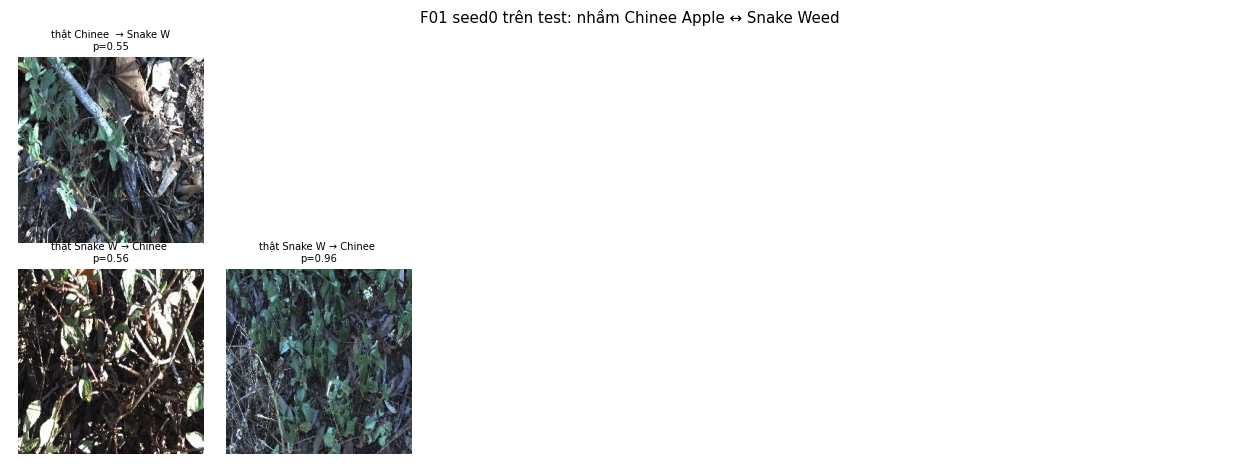

In [59]:
# Phân tích lỗi: ma trận nhầm lẫn (cộng 3 seed) và ảnh bị đoán sai
from IPython.display import Image, display
print(pd.read_csv(SUB + '/eval_out/F01_confusion_sum.csv', index_col=0).to_string())
print(pd.read_csv(SUB + '/eval_out/T00_confusion_sum.csv', index_col=0).to_string())
display(Image(SUB + '/figures/errors_chinee_snake.png', width=1000))

In [60]:
# Đưa báo cáo/README/notebook sạch lên thư mục bài nộp; lưu bản notebook đã chạy vào code/
import tarfile, shutil, glob
with tarfile.open('/content/code_bundle.tgz') as t: t.extractall(SUB); print(t.getnames())
os.remove('/content/code_bundle.tgz')
src = glob.glob('/content/drive/MyDrive/Colab Notebooks/Untitled8.ipynb'); print(src)
if src: shutil.copy(src[0], CODE + '/lab_day2_run.ipynb')
print(json.load(open(SUB + '/runs/F01/seed1/summary.json'))['versions'])
!ls -la {SUB} {CODE}

/tmp/ipykernel_1601/1147160897.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open('/content/code_bundle.tgz') as t: t.extractall(SUB); print(t.getnames())


['report.md', 'README.md', 'code/lab_day2.ipynb']
['/content/drive/MyDrive/Colab Notebooks/Untitled8.ipynb']
{'python': '3.13.15', 'torch': '2.11.0+cu130', 'torchvision': '0.26.0+cu130', 'timm': '1.0.29', 'numpy': '2.1.3', 'gpu': 'Tesla T4'}
/content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/MSSV_ho_ten:
total 99
drwx------ 11 root root  4096 Oct  4 18:39 .
drwx------  3 root root  4096 Oct  4 15:25 ..
drwx------  3 root root  4096 Oct  4 18:39 code
drwx------  2 root root  4096 Oct  4 18:35 curves
drwx------  4 root root  4096 Oct  4 17:54 discarded_F01_combo
drwx------  2 root root  4096 Oct  4 18:34 eval_out
drwx------  2 root root  4096 Oct  4 18:34 figures
drwx------  2 root root  4096 Oct  4 18:33 logs
drwx------  2 root root  4096 Oct  4 18:33 predictions
-rw-------  1 root root  3651 Oct  4 16:12 README.md
-rw-------  1 root root 30144 Oct  4 18:38 report.md
-rw-------  1 root root 21640 Oct  4 18:34 results.xlsx
drwx------ 20 root root  4096 Oct  4 17

{'Summary': (13, 11), 'Backbones': (5, 18), 'Training': (11, 16), 'Inference': (19, 18), 'Final': (9, 14), 'PerClass': (18, 6), 'Latency': (14, 15)}
exp_id           stage                                                                                 description    val_macro_f1   test_macro_f1       test_top1        test_ece
   F01    FINAL (test) convnext_tiny + công thức {mix=cutmix} + I04_res288 + temperature scaling (T khớp trên val) 0.9719 ± 0.0004 0.9750 ± 0.0026 0.9792 ± 0.0020 0.0072 ± 0.0015
   T00 BASELINE (test)                                        convnext_tiny + công thức nền T00 + 1-view I00 (mốc) 0.9684 ± 0.0011 0.9706 ± 0.0020 0.9765 ± 0.0023 0.0097 ± 0.0005
   NaN             NaN                                                                                         NaN             NaN             NaN             NaN             NaN
   I04       Inference                                                                                  I04_res288        0.975584     

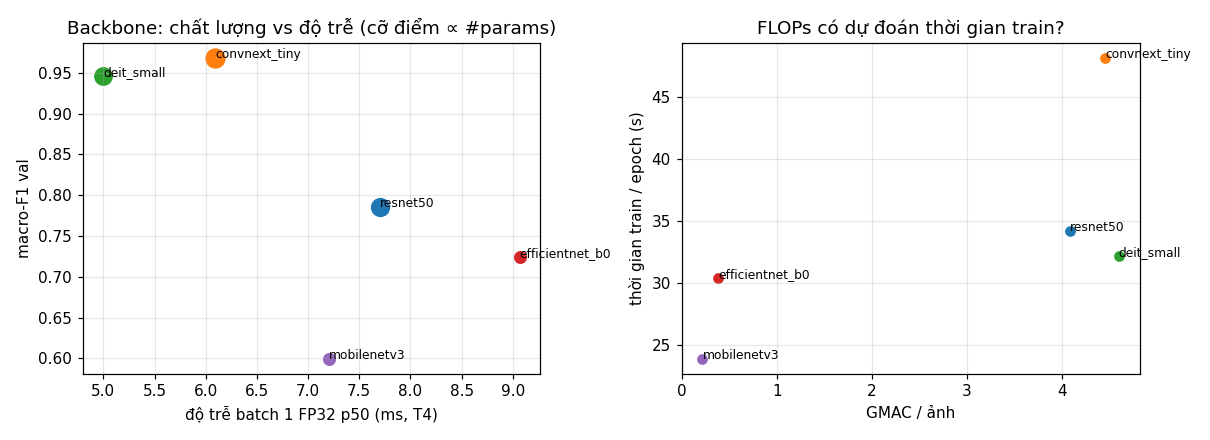

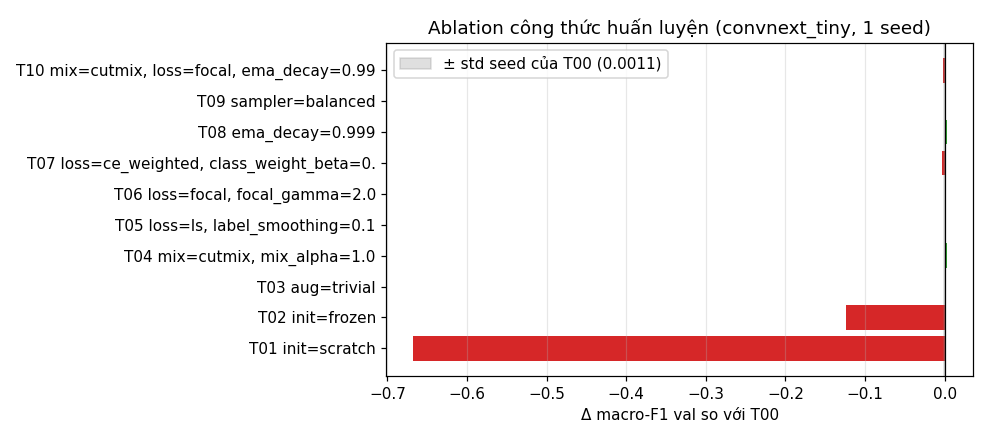

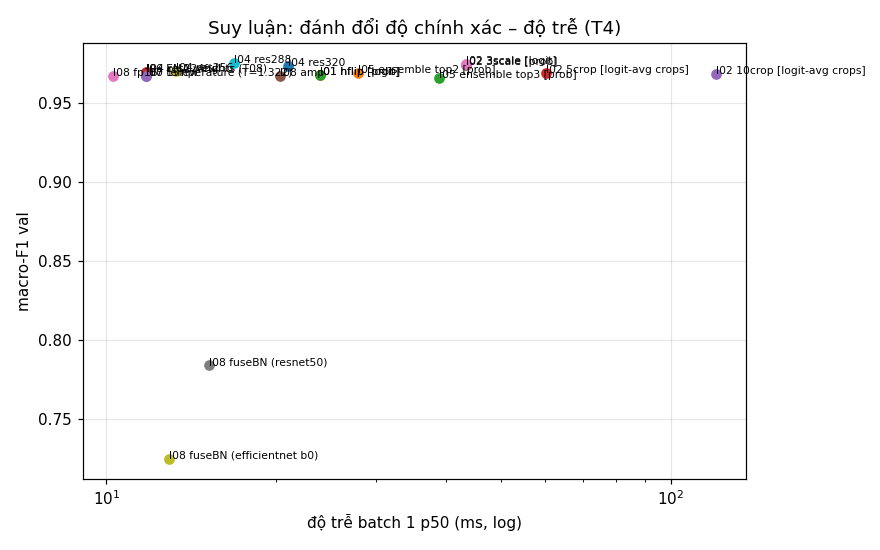

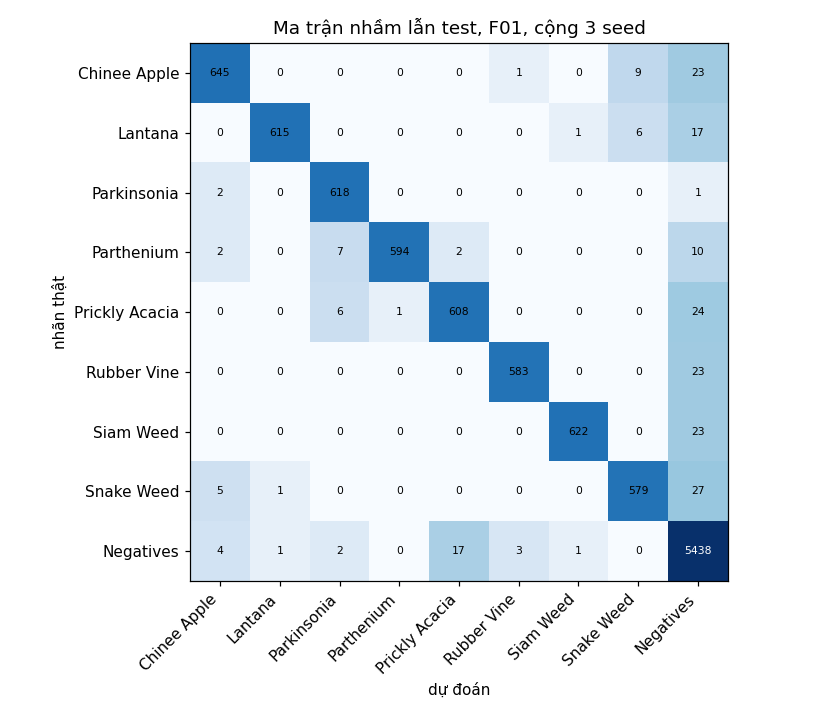

In [61]:
# Kiểm tra hình và sheet Summary
x = pd.read_excel(SUB + '/results.xlsx', sheet_name=None); print({k: v.shape for k, v in x.items()})
print(x['Summary'].iloc[:, :7].to_string(index=False)[:1800])
for f in ('backbones_tradeoff', 'training_ablation', 'inference_tradeoff', 'confusion_F01'):
    display(Image(f'{SUB}/figures/{f}.png', width=640))

/tmp/ipykernel_1601/420066183.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open('/content/code_bundle.tgz') as t: t.extractall(SUB); print(t.getnames())


['README.md', 'code/lab_day2.ipynb', 'code/make_results.py']
đã ghi /content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/MSSV_ho_ten/results.xlsx


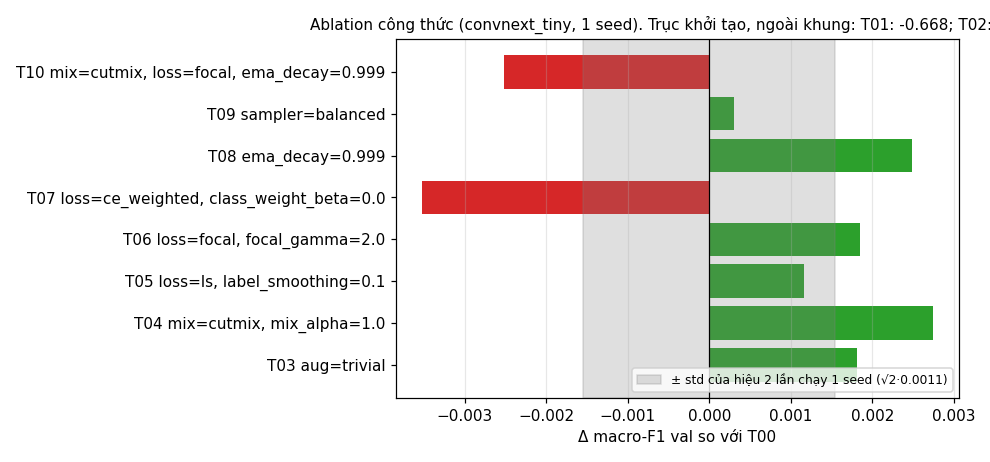

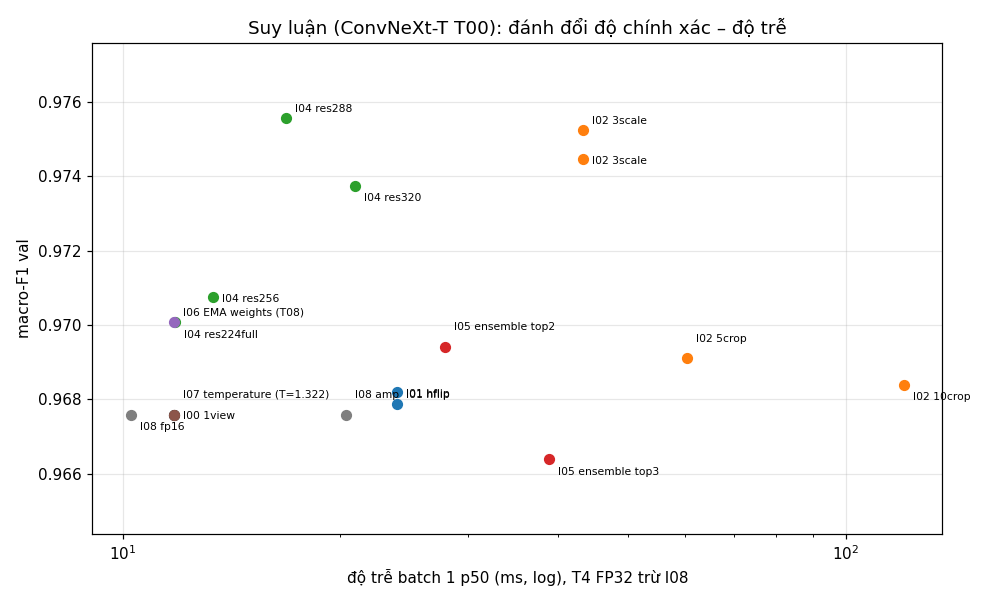

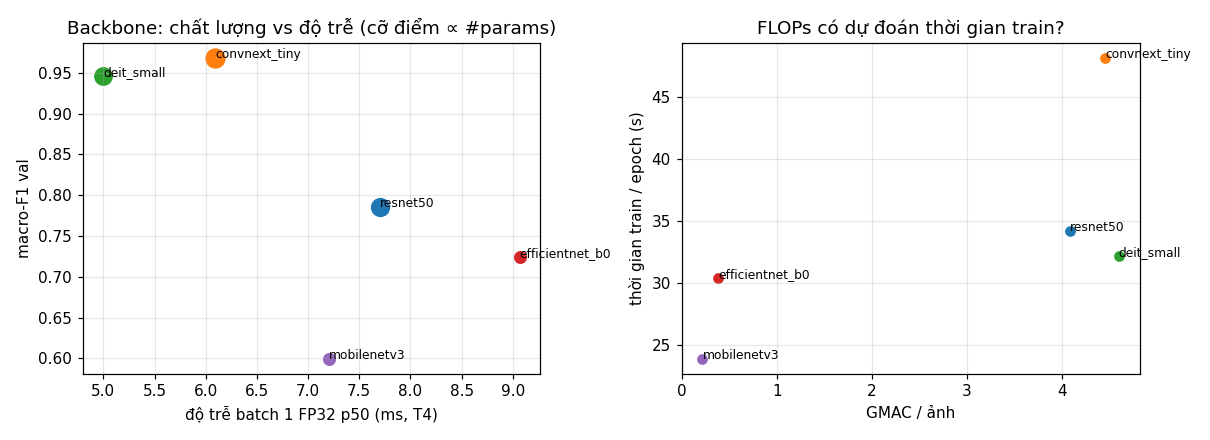

In [62]:
# Cập nhật README/notebook/make_results rồi vẽ lại
with tarfile.open('/content/code_bundle.tgz') as t: t.extractall(SUB); print(t.getnames())
os.remove('/content/code_bundle.tgz')
!python make_results.py --backbone convnext_tiny 2>&1 | grep -v -i warn | tail -2
for f in ('training_ablation', 'inference_tradeoff', 'backbones_tradeoff'):
    display(Image(f'{SUB}/figures/{f}.png', width=760))

In [46]:
# Bước 2 (kết hợp T10) + Bước 4 (chung kết 3 seed) — chạy sau khi stage inference xong (có inference_choice.json)
COMBO = 'mix=cutmix loss=focal ema_decay=0.999'   # tốt nhất mỗi trục trên val: B=CutMix (+0.0027), C=focal (+0.0018), F=EMA (+0.0025)
wait = f'while [ ! -f {SUB}/tables/inference_choice.json ] || pgrep -f "[s]tage (training|inference)" >/dev/null; do sleep 20; done'
cmd = (f'python run_experiments.py --stage combo --backbone convnext_tiny --combo "{COMBO}" && '
       f'python run_experiments.py --stage final --backbone convnext_tiny --combo "{COMBO}" --seeds 0,1,2')
open('/content/step4.sh', 'w').write(wait + '; ' + cmd + '\n')
subprocess.Popen(f'nohup sh /content/step4.sh > {SUB}/logs/step4_combo_final.log 2>&1 &', shell=True, cwd=CODE)
print(open('/content/step4.sh').read())

while [ ! -f /content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/MSSV_ho_ten/tables/inference_choice.json ] || pgrep -f "[s]tage (training|inference)" >/dev/null; do sleep 20; done; python run_experiments.py --stage combo --backbone convnext_tiny --combo "mix=cutmix loss=focal ema_decay=0.999" && python run_experiments.py --stage final --backbone convnext_tiny --combo "mix=cutmix loss=focal ema_decay=0.999" --seeds 0,1,2



In [21]:
# Bước 2: ablation công thức huấn luyện trên ConvNeXt-T (chạy sau khi stage backbones xong)
def launch_after(name, wait_pattern, *stages):
    os.makedirs(f'{SUB}/logs', exist_ok=True)
    cmd = ' && '.join(f'python run_experiments.py {s}' for s in stages)
    full = f'while pgrep -f "{wait_pattern}" >/dev/null; do sleep 20; done; {cmd}'
    subprocess.Popen(f"nohup sh -c '{full}' > {SUB}/logs/{name}.log 2>&1 &", shell=True, cwd=CODE)
    print('queued', name, ':', full)
!pkill -f 'while pgrep' ; sleep 1
launch_after('step2_training', '[s]tage backbones', '--stage training --backbone convnext_tiny')

^C
queued step2_training : while pgrep -f "[s]tage backbones" >/dev/null; do sleep 20; done; python run_experiments.py --stage training --backbone convnext_tiny


In [43]:
# Bước 3: suy luận + độ trễ (chạy sau khi stage training xong; chỉ dùng val)
launch_after('step3_inference', '[s]tage training', '--stage inference --backbone convnext_tiny')

queued step3_inference : while pgrep -f "[s]tage training" >/dev/null; do sleep 20; done; python run_experiments.py --stage inference --backbone convnext_tiny


In [40]:
# Bảng tóm tắt các lần chạy đã xong
import glob, json, pandas as pd
rows = [json.load(open(f)) for f in sorted(glob.glob(SUB + '/runs/*/seed*/summary.json'))]
df = pd.DataFrame(rows)[['exp_id','seed','backbone','desc','best_epoch','val_macro_f1','val_top1','train_time_per_epoch_s','latency_b1_fp32_p50_ms','params_M','gmacs']]
df['f1_chinee'] = [r['val_f1_per_class'][0] for r in rows]; df['f1_snake'] = [r['val_f1_per_class'][7] for r in rows]
print(df.round(4).to_string(index=False))

exp_id  seed        backbone            desc  best_epoch  val_macro_f1  val_top1  train_time_per_epoch_s  latency_b1_fp32_p50_ms  params_M  gmacs  f1_chinee  f1_snake
   B01     0        resnet50        resnet50           9        0.7850    0.8446                 34.2564                  7.7052   23.5265 4.0872     0.6041    0.7147
   B02     0   convnext_tiny   convnext_tiny           9        0.9676    0.9760                 48.1568                  6.0892   27.8270 4.4548     0.9321    0.9265
   B03     0      deit_small      deit_small           9        0.9460    0.9617                 32.2339                  4.9999   21.6691 4.5985     0.8730    0.8894
   B04     0 efficientnet_b0 efficientnet_b0           7        0.7238    0.8021                 30.4578                  9.0661    4.0191 0.3845     0.6194    0.6912
   B05     0     mobilenetv3     mobilenetv3           7        0.5997    0.7207                 23.9023                  7.2036    4.2136 0.2153     0.6240    0.490